# Adult Census Income Classification

## 1. Problem Definition

Predict whether an individual's recorded annual income belongs to the dataset's higher-income or lower-income category using recorded demographic and employment-related features.

- **Task type:** Binary classification.
- **Positive class:** Income > $50K.

Compare logistic regression, decision trees, and random forests against a dummy baseline to determine which model performs best for this classification task.

## 2. Imports and Reproducibility

In [149]:
from sklearn.datasets import fetch_openml
from sklearn import set_config

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Dataset Loading

In [65]:
data = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = data.frame.copy()

## 4. Exploratory Data Analysis (EDA)

In [66]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [68]:
df.shape

(48842, 15)

In [69]:
df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

In [70]:
categorical_features = df.select_dtypes(include="category").columns
numerical_features = df.select_dtypes(include="number").columns

df[categorical_features].nunique()

workclass          8
education         16
marital-status     7
occupation        14
relationship       6
race               5
sex                2
native-country    41
class              2
dtype: int64

In [71]:
df[categorical_features].describe()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


In [72]:
for column in categorical_features:
    print(column)
    print(df[column].unique())
    print()

workclass
['Private', 'Local-gov', NaN, 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Categories (8, str): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

education
['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', ..., 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool']
Length: 16
Categories (16, str): ['10th', '11th', '12th', '1st-4th', ..., 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital-status
['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated', 'Married-spouse-absent', 'Married-AF-spouse']
Categories (7, str): ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation
['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', NaN, 'Other-service', ..., 'Sales', 'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners', 'Armed-Forces']
Leng

In [73]:
for column in categorical_features:
    print(df[column].value_counts(dropna=False))
    print()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial   

In [74]:
for column in numerical_features:
    print(column)
    print(df[column].describe())
    print()

age
count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

fnlwgt
count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

education-num
count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

capital-gain
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

capital-loss
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%  

In [75]:
corr = df[numerical_features].corr()
corr

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
education-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


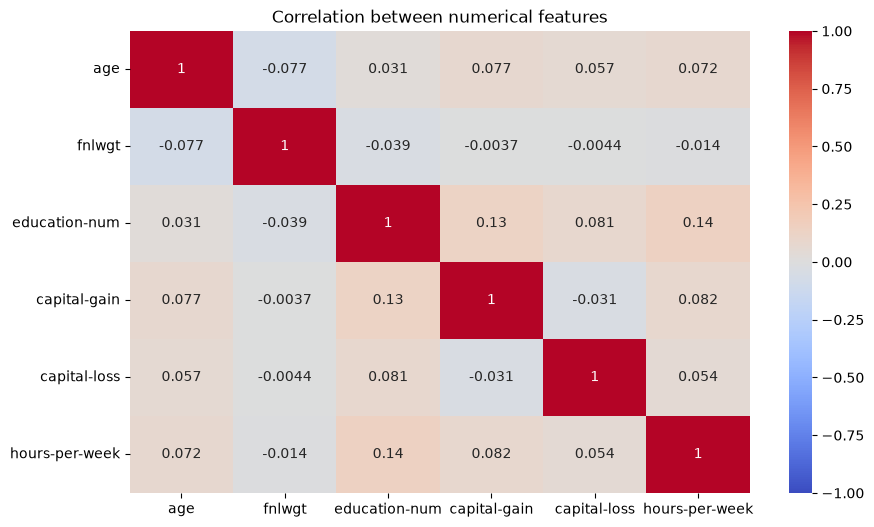

In [76]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numerical features")
plt.show()

In [77]:
df[["education", "education-num"]].drop_duplicates().sort_values("education-num")

,education,education-num
779,Preschool,1
323,1st-4th,2
37,5th-6th,3
9,7th-8th,4
54,9th,5
5,10th,6
0,11th,7
173,12th,8
1,HS-grad,9
3,Some-college,10


In [78]:
missing_values = pd.DataFrame({
    "count": df.isna().sum(),
    "percentage": round(df.isna().mean() * 100, 2)
})

missing_values[missing_values["count"] > 0]

,count,percentage
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


In [79]:
df.duplicated().sum()

np.int64(52)

In [80]:
duplicates = df[df.duplicated(keep=False)]

duplicates

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
488,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
1319,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
1854,22,Private,137876,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,20,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46665,20,NaN,203353,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,40,United-States,<=50K
46979,22,NaN,334593,Some-college,10,Never-married,NaN,Not-in-family,White,Male,0,0,40,United-States,<=50K
47126,46,Private,133616,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48274,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K


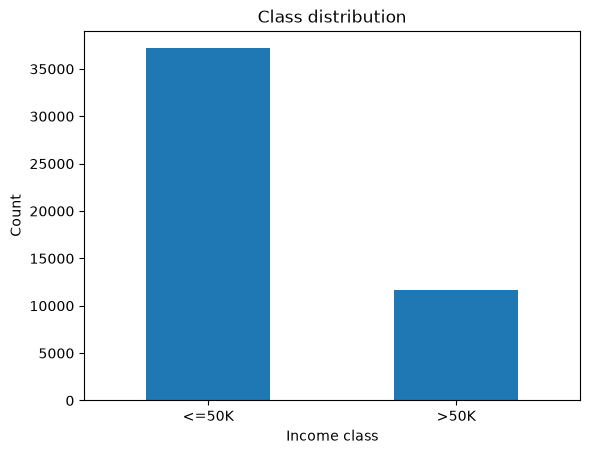

In [81]:
df["class"].value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.title("Class distribution")
plt.xlabel("Income class")
plt.ylabel("Count")
plt.show()

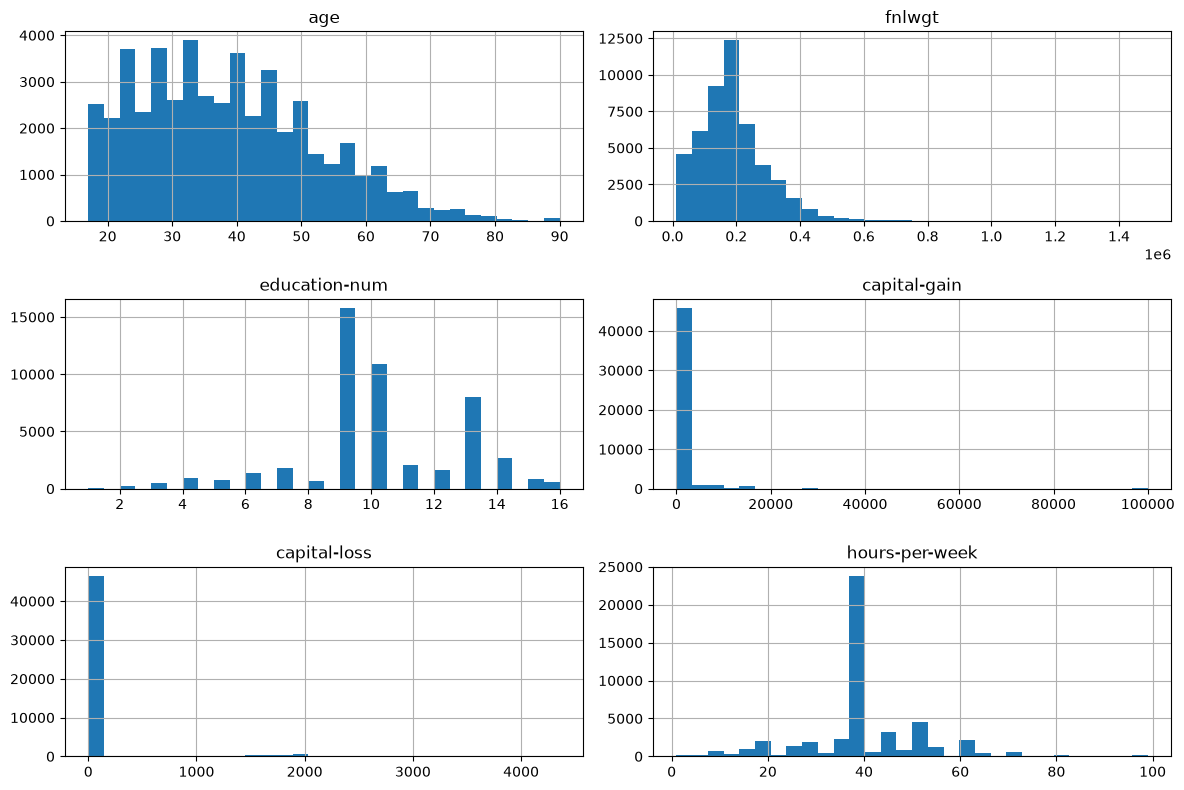

In [82]:
df[numerical_features].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

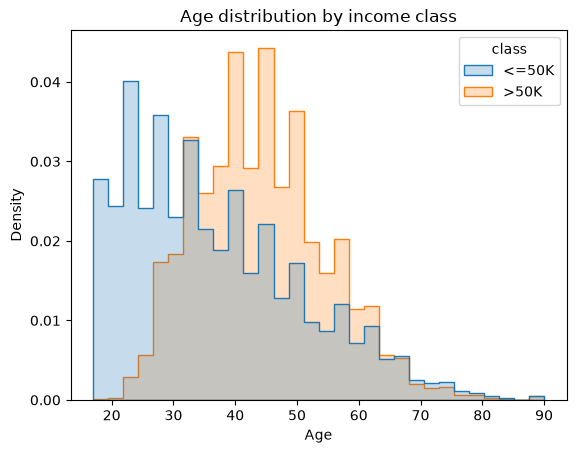

In [83]:
sns.histplot(
    data=df,
    x="age",
    hue="class",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Age distribution by income class")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

In [84]:
education_class = pd.crosstab(
    df["education"],
    df["class"],
    normalize="index"
)

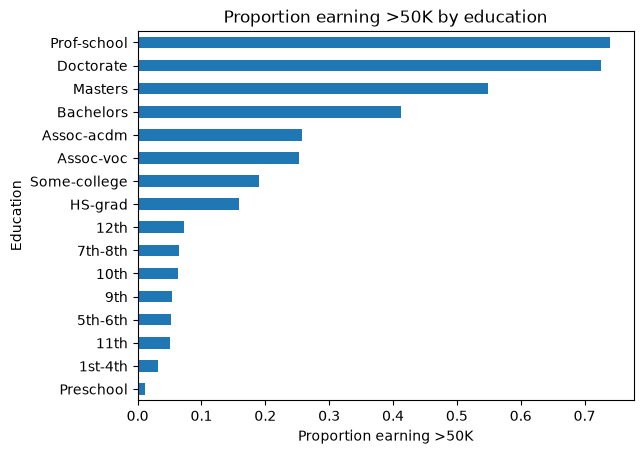

In [85]:
education_class[">50K"].sort_values().plot(kind="barh")

plt.xlabel("Proportion earning >50K")
plt.ylabel("Education")
plt.title("Proportion earning >50K by education")
plt.show()

### Initial data assessment

- **Dataset structure**
  - 48,842 observations and 15 columns.
  - 14 predictors and one binary target, `class`.
  - The original predictor set contains six numerical and eight categorical features.

- **Target distribution**
  - Approximately 76% of observations belong to the `<=50K` class and 24% to the `>50K` class.
  - `>50K` will be treated as the positive class.
  - Because the target is imbalanced, stratified splitting will be used during model development.

- **Categorical features**
  - Categorical predictors contain between 2 and 41 observed categories.
  - Several rare categories are present, particularly within `native-country`, although the overall cardinality remains manageable for one-hot encoding.
  - Missing values occur in `workclass`, `occupation`, and `native-country`.
  - Missing categorical values will be handled later within the preprocessing pipeline.

- **Numerical features**
  - Numerical features have substantially different scales and distributions.
  - `capital-gain` and `capital-loss` are particularly zero-heavy and right-skewed.
  - The correlation matrix shows no strong pairwise linear correlations between the numerical predictors, so no obvious numerical multicollinearity problem was identified.

- **Exploratory relationships with the target**
  - The `>50K` class is concentrated more strongly among middle-aged observations, while the `<=50K` class contains a greater proportion of younger observations, although the age distributions overlap substantially.
  - Higher educational attainment is generally associated with a greater observed proportion of records belonging to the `>50K` class.
  - These relationships are descriptive and should not be interpreted as causal.

- **Feature decisions**
  - `education` and `education-num` encode the same underlying educational-attainment information.
  - `education-num` will therefore be removed and `education` retained as a categorical feature.
  - `education` will later be one-hot encoded so that the models are not forced to assume fixed numerical spacing between educational levels.
  - `fnlwgt` represents a Census survey sampling weight rather than a direct individual characteristic within the intended prediction problem, so it will also be excluded from the predictor set.

- **Duplicate records**
  - 52 exact duplicate rows were identified.
  - Because there is no unique individual identifier, it is not possible to determine whether these are repeated records or distinct individuals with identical recorded attributes.
  - Given their very small proportion of the dataset, exact duplicates will be removed before data splitting to prevent identical records from appearing across development and test sets.

- **Resulting modelling dataset**
  - After removing `education-num` and `fnlwgt`, the dataset will contain 12 predictors:
    - four numerical features;
    - eight categorical features.
  - These findings determine the feature set, preprocessing requirements, stratified evaluation strategy, and construction of the model pipelines.

## 5. Data Preparation

In [86]:
model_df = df.copy()

In [89]:
model_df = model_df.drop_duplicates()
model_df.shape

(48790, 15)

In [90]:
model_df.duplicated().sum()

np.int64(0)

In [91]:
model_df = model_df.drop(columns=["education-num", "fnlwgt"])

In [92]:
model_df.shape

(48790, 13)

In [93]:
X = model_df.drop(columns=["class"])
y = model_df["class"]

In [94]:
X.shape

(48790, 12)

In [95]:
y.shape

(48790,)

In [96]:
# Encode the target variable
y = y.map({">50K": 1, "<=50K": 0})

In [97]:
y.value_counts()

class
0    37109
1    11681
Name: count, dtype: int64

In [98]:
y.isna().sum()

np.int64(0)

In [100]:
numerical_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(include="category").columns

In [101]:
numerical_features

Index(['age', 'capital-gain', 'capital-loss', 'hours-per-week'], dtype='str')

In [102]:
categorical_features

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='str')

In [103]:
len(numerical_features), len(categorical_features)

(4, 8)

## 6. Train-Test Split and Stratification

In [ ]:
# preserve class balance in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [110]:
y_train.value_counts(normalize=True)

class
0    0.760581
1    0.239419
Name: proportion, dtype: float64

In [112]:
y_test.value_counts(normalize=True)

class
0    0.760607
1    0.239393
Name: proportion, dtype: float64

In [ ]:
# preserve class balance in cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 7. Dummy Baseline Model

In [115]:
dummy_model = DummyClassifier(strategy="most_frequent")

In [131]:
scoring = [
    "balanced_accuracy",
    "accuracy",
    "precision",
    "recall",
    "f1",
]

In [132]:
dummy_results = cross_validate(dummy_model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
dummy_results

/Users/simonyip/adult-income-ml-classification/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/simonyip/adult-income-ml-classification/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/simonyip/adult-income-ml-classification/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

{'fit_time': array([0.00522304, 0.0024488 , 0.00161719, 0.00237393, 0.00165606]),
 'score_time': array([0.01578307, 0.00716114, 0.00734901, 0.00643134, 0.00631499]),
 'test_balanced_accuracy': array([0.5, 0.5, 0.5, 0.5, 0.5]),
 'train_balanced_accuracy': array([0.5, 0.5, 0.5, 0.5, 0.5]),
 'test_accuracy': array([0.76059946, 0.76059946, 0.76056879, 0.76056879, 0.76056879]),
 'train_accuracy': array([0.76057646, 0.76057646, 0.76058413, 0.76058413, 0.76058413]),
 'test_precision': array([0., 0., 0., 0., 0.]),
 'train_precision': array([0., 0., 0., 0., 0.]),
 'test_recall': array([0., 0., 0., 0., 0.]),
 'train_recall': array([0., 0., 0., 0., 0.]),
 'test_f1': array([0., 0., 0., 0., 0.]),
 'train_f1': array([0., 0., 0., 0., 0.])}

In [146]:
dummy_summary = pd.DataFrame({
    "Metric": [
        "Balanced accuracy",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ],
    "Mean CV score": [
        dummy_results["test_balanced_accuracy"].mean().round(3),
        dummy_results["test_accuracy"].mean().round(3),
        dummy_results["test_precision"].mean().round(3),
        dummy_results["test_recall"].mean().round(3),
        dummy_results["test_f1"].mean().round(3),
    ],
    "CV std": [
        dummy_results["test_balanced_accuracy"].std().round(3),
        dummy_results["test_accuracy"].std().round(3),
        dummy_results["test_precision"].std().round(3),
        dummy_results["test_recall"].std().round(3),
        dummy_results["test_f1"].std().round(3),
    ],
})

dummy_summary

,Metric,Mean CV score,CV std
0,Balanced accuracy,0.500,0.0
1,Accuracy,0.761,0.0
2,Precision,0.000,0.0
3,Recall,0.000,0.0
4,F1,0.000,0.0


## 8. Preprocessing Pipeline

In [155]:
categorical_preprocessing = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

scaler = StandardScaler()

linear_preprocessing = ColumnTransformer(
    transformers=[
        ("categorical", categorical_preprocessing, categorical_features),
        ("numerical", scaler, numerical_features),
    ]
)

tree_preprocessing = ColumnTransformer(
    transformers=[
        ("categorical", categorical_preprocessing, categorical_features),
        ("numerical", "passthrough", numerical_features),
    ]
)

## 9. Model Development and Cross-Validation

## 10. Cross-Validation Comparison